# Job Market Analysis
### By: Your Name
### Date: June 2026

## Project Overview
This project analyzes job market trends for data science positions.
The dataset contains 742 rows and 42 features including job titles, 
salaries, skills, industries and locations across the United States.
The goal is to identify most in-demand skills, top hiring companies,
salary trends and provide insights for job seekers and employers.

## Step 1 - Importing Libraries

In [69]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Step 2 - Loading the Dataset

In [52]:
# Load the dataset
df = pd.read_csv('market_analysis.csv')

# Check shape
print("Rows and Columns:", df.shape)

Rows and Columns: (742, 42)


In [53]:
# See first 5 rows
df.head()

,ID,Job_Title,Salary_Estimate,FIELD4,Rating,Company_Name,Location,Headquarters,Size,Founded,...,tensor,hadoop,tableau,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,Degree
0,0,Data Scientist,$53K-$91K (Glassdoor est.),NaN,3.8,Tecolote Research\n3.8,"Albuquerque, NM","Goleta, CA",501 - 1000,1973,...,0,0,1,1,0,0,0,data scientist,na,M
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),NaN,3.4,University of Maryland Medical System\n3.4,"Linthicum, MD","Baltimore, MD",10000+,1984,...,0,0,0,0,0,0,0,data scientist,na,M
2,2,Data Scientist,$80K-$90K (Glassdoor est.),NaN,4.8,KnowBe4\n4.8,"Clearwater, FL","Clearwater, FL",501 - 1000,2010,...,0,0,0,0,0,0,0,data scientist,na,M
3,3,Data Scientist,$56K-$97K (Glassdoor est.),NaN,3.8,PNNL\n3.8,"Richland, WA","Richland, WA",1001 - 5000,1965,...,0,0,0,0,0,0,0,data scientist,na,na
4,4,Data Scientist,$86K-$143K (Glassdoor est.),NaN,2.9,Affinity Solutions\n2.9,"New York, NY","New York, NY",51 - 200,1998,...,0,0,0,0,0,0,0,data scientist,na,na


In [54]:
len(df.columns)

42

In [55]:
df.isnull().sum()

ID                      0
Job_Title               0
Salary_Estimate         0
FIELD4                742
Rating                  0
Company_Name            0
Location                0
Headquarters            0
Size                    0
Founded                 0
Type_of_ownership       0
Industry                0
Sector                  0
Revenue                 0
Competitors             0
Hourly                  0
Employer_provided       0
Lower_Salary            0
Upper_Salary            0
Avg_SalaryK             0
company_txt             0
Job_Location            0
Age                     0
Python                  0
spark                   0
aws                     0
excel                   0
sql_                    0
sas                     0
keras                   0
pytorch                 0
scikit                  0
tensor                  0
hadoop                  0
tableau                 0
bi                      0
flink                   0
mongo                   0
google_an   

In [56]:
# Check FIELD4
print("FIELD4 unique values:", df['FIELD4'].unique())
print("FIELD4 missing count:", df['FIELD4'].isnull().sum())

FIELD4 unique values: [nan]
FIELD4 missing count: 742


In [57]:
# Drop FIELD4 column
df = df.drop(columns=['FIELD4'])
print("✅ FIELD4 dropped!")
print("Remaining Columns:", df.shape[1])

✅ FIELD4 dropped!
Remaining Columns: 41


In [58]:
df.isnull().sum()

ID                    0
Job_Title             0
Salary_Estimate       0
Rating                0
Company_Name          0
Location              0
Headquarters          0
Size                  0
Founded               0
Type_of_ownership     0
Industry              0
Sector                0
Revenue               0
Competitors           0
Hourly                0
Employer_provided     0
Lower_Salary          0
Upper_Salary          0
Avg_SalaryK           0
company_txt           0
Job_Location          0
Age                   0
Python                0
spark                 0
aws                   0
excel                 0
sql_                  0
sas                   0
keras                 0
pytorch               0
scikit                0
tensor                0
hadoop                0
tableau               0
bi                    0
flink                 0
mongo                 0
google_an             0
job_title_sim         0
seniority_by_title    0
Degree                0
dtype: int64

## Step 3 - Dropping Unnecessary Columns
Removing columns that are not required for our analysis tasks.

In [59]:
# Drop unused columns
cols_to_drop = [
    'ID', 'Salary_Estimate', 'Headquarters', 'Size',
    'Founded', 'Type_of_ownership', 'Revenue', 'Competitors',
    'Hourly', 'Employer_provided', 'company_txt', 'Age',
    'flink', 'mongo', 'google_an'
]

df = df.drop(columns=cols_to_drop)
print("Unused columns dropped!")
print("Remaining Columns:", df.shape[1])
print("\nFinal Columns:")
for col in df.columns:
    print(f"   {col}")

Unused columns dropped!
Remaining Columns: 26

Final Columns:
   Job_Title
   Rating
   Company_Name
   Location
   Industry
   Sector
   Lower_Salary
   Upper_Salary
   Avg_SalaryK
   Job_Location
   Python
   spark
   aws
   excel
   sql_
   sas
   keras
   pytorch
   scikit
   tensor
   hadoop
   tableau
   bi
   job_title_sim
   seniority_by_title
   Degree


In [60]:
len(df.columns)

26

In [61]:
# See remaining columns
print("Final Columns:")
print("-" * 30)
for col in df.columns:
    print(f" {col}")

Final Columns:
------------------------------
 Job_Title
 Rating
 Company_Name
 Location
 Industry
 Sector
 Lower_Salary
 Upper_Salary
 Avg_SalaryK
 Job_Location
 Python
 spark
 aws
 excel
 sql_
 sas
 keras
 pytorch
 scikit
 tensor
 hadoop
 tableau
 bi
 job_title_sim
 seniority_by_title
 Degree


In [63]:
#Fix Company Name properly
import re
df['Company_Name'] = df['Company_Name'].apply(lambda x: 
    re.sub(r'\n.*', '', str(x)).strip() if isinstance(x, str) else x)

print("Company Names fixed!")
print(df['Company_Name'].head(10))

Company Names fixed!
0                        Tecolote Research
1    University of Maryland Medical System
2                                  KnowBe4
3                                     PNNL
4                       Affinity Solutions
5                                 CyrusOne
6                       ClearOne Advantage
7                               Logic20/20
8                Rochester Regional Health
9                                 <intent>
Name: Company_Name, dtype: object


## Step 4 - Checking Missing Values
Checking all columns for missing/null values.

In [64]:
# Check missing values
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Percentage %': (df.isnull().sum() / len(df)) * 100
})

# Show only columns with missing values
missing = missing[missing['Missing Count'] > 0]
print("Columns with Missing Values:")
print(missing)

Columns with Missing Values:
Empty DataFrame
Columns: [Missing Count, Percentage %]
Index: []


## Step 5 - Checking Duplicates

In [65]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

# Drop duplicates if any
df = df.drop_duplicates()
print("After Removing Duplicates:", df.shape)

Duplicate Rows: 275
After Removing Duplicates: (467, 26)


## Step 6 - Fixing Missing Values
Filling missing values in Rating and Founded columns with median.

In [70]:
# Fill Rating missing values with median
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
print("Rating missing values filled!")
print("Rating missing now:", df['Rating'].isnull().sum())

Rating missing values filled!
Rating missing now: 0


In [71]:
# Replace -1 values with NaN first
df['Rating'] = df['Rating'].replace(-1, np.nan)
df['Rating'] = df['Rating'].fillna(df['Rating'].median())
print("Rating -1 values fixed!")

Rating -1 values fixed!


In [72]:
# Confirm no missing values remaining
print("Total Missing Values Now:")
print(df.isnull().sum().sum())
print(" No missing values!" if df.isnull().sum().sum() == 0 else "⚠️ Still has missing values!")

Total Missing Values Now:
0
 No missing values!


## Step 7 - Standardizing Categorical Columns
Cleaning text columns by removing extra spaces and 
converting to consistent format.

In [73]:
# Standardize Job_Title
df['Job_Title'] = df['Job_Title'].str.strip().str.title()
print("Job_Title standardized!")
print(df['Job_Title'].unique()[:5])

Job_Title standardized!
['Data Scientist' 'Healthcare Data Scientist' 'Research Scientist'
 'Staff Data Scientist - Technology' 'Data Analyst']


In [74]:
# Standardize Company_Name
df['Company_Name'] = df['Company_Name'].str.strip().str.title()
print("Company_Name standardized!")
print(df['Company_Name'].unique()[:5])

Company_Name standardized!
['Tecolote Research' 'University Of Maryland Medical System' 'Knowbe4'
 'Pnnl' 'Affinity Solutions']


In [75]:
# Standardize Location, Industry, Sector
df['Location'] = df['Location'].str.strip().str.title()
df['Industry'] = df['Industry'].str.strip().str.title()
df['Sector'] = df['Sector'].str.strip().str.title()
df['Job_Location'] = df['Job_Location'].str.strip().str.upper()
print("Location, Industry, Sector standardized!")

Location, Industry, Sector standardized!


In [76]:
# Standardize job_title_sim and seniority_by_title
df['job_title_sim'] = df['job_title_sim'].str.strip().str.title()
df['seniority_by_title'] = df['seniority_by_title'].str.strip().str.title()
df['Degree'] = df['Degree'].str.strip().str.upper()
print("job_title_sim, seniority, Degree standardized!")

job_title_sim, seniority, Degree standardized!


## Step 8 - Checking Outliers
Visualizing outliers in all numerical columns using Boxplots.

In [77]:
# Get all numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical Columns:", len(num_cols))
print(num_cols)

Numerical Columns: 17
['Rating', 'Lower_Salary', 'Upper_Salary', 'Avg_SalaryK', 'Python', 'spark', 'aws', 'excel', 'sql_', 'sas', 'keras', 'pytorch', 'scikit', 'tensor', 'hadoop', 'tableau', 'bi']


In [78]:
# Check outliers using IQR method
print("Outlier Detection Results:")
print("-" * 40)
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: {outliers} outliers found")

Outlier Detection Results:
----------------------------------------
Rating: 8 outliers found
Lower_Salary: 11 outliers found
Upper_Salary: 9 outliers found
Avg_SalaryK: 8 outliers found
Python: 0 outliers found
spark: 111 outliers found
aws: 111 outliers found
excel: 0 outliers found
sql_: 0 outliers found
sas: 42 outliers found
keras: 19 outliers found
pytorch: 24 outliers found
scikit: 37 outliers found
tensor: 48 outliers found
hadoop: 82 outliers found
tableau: 99 outliers found
bi: 39 outliers found


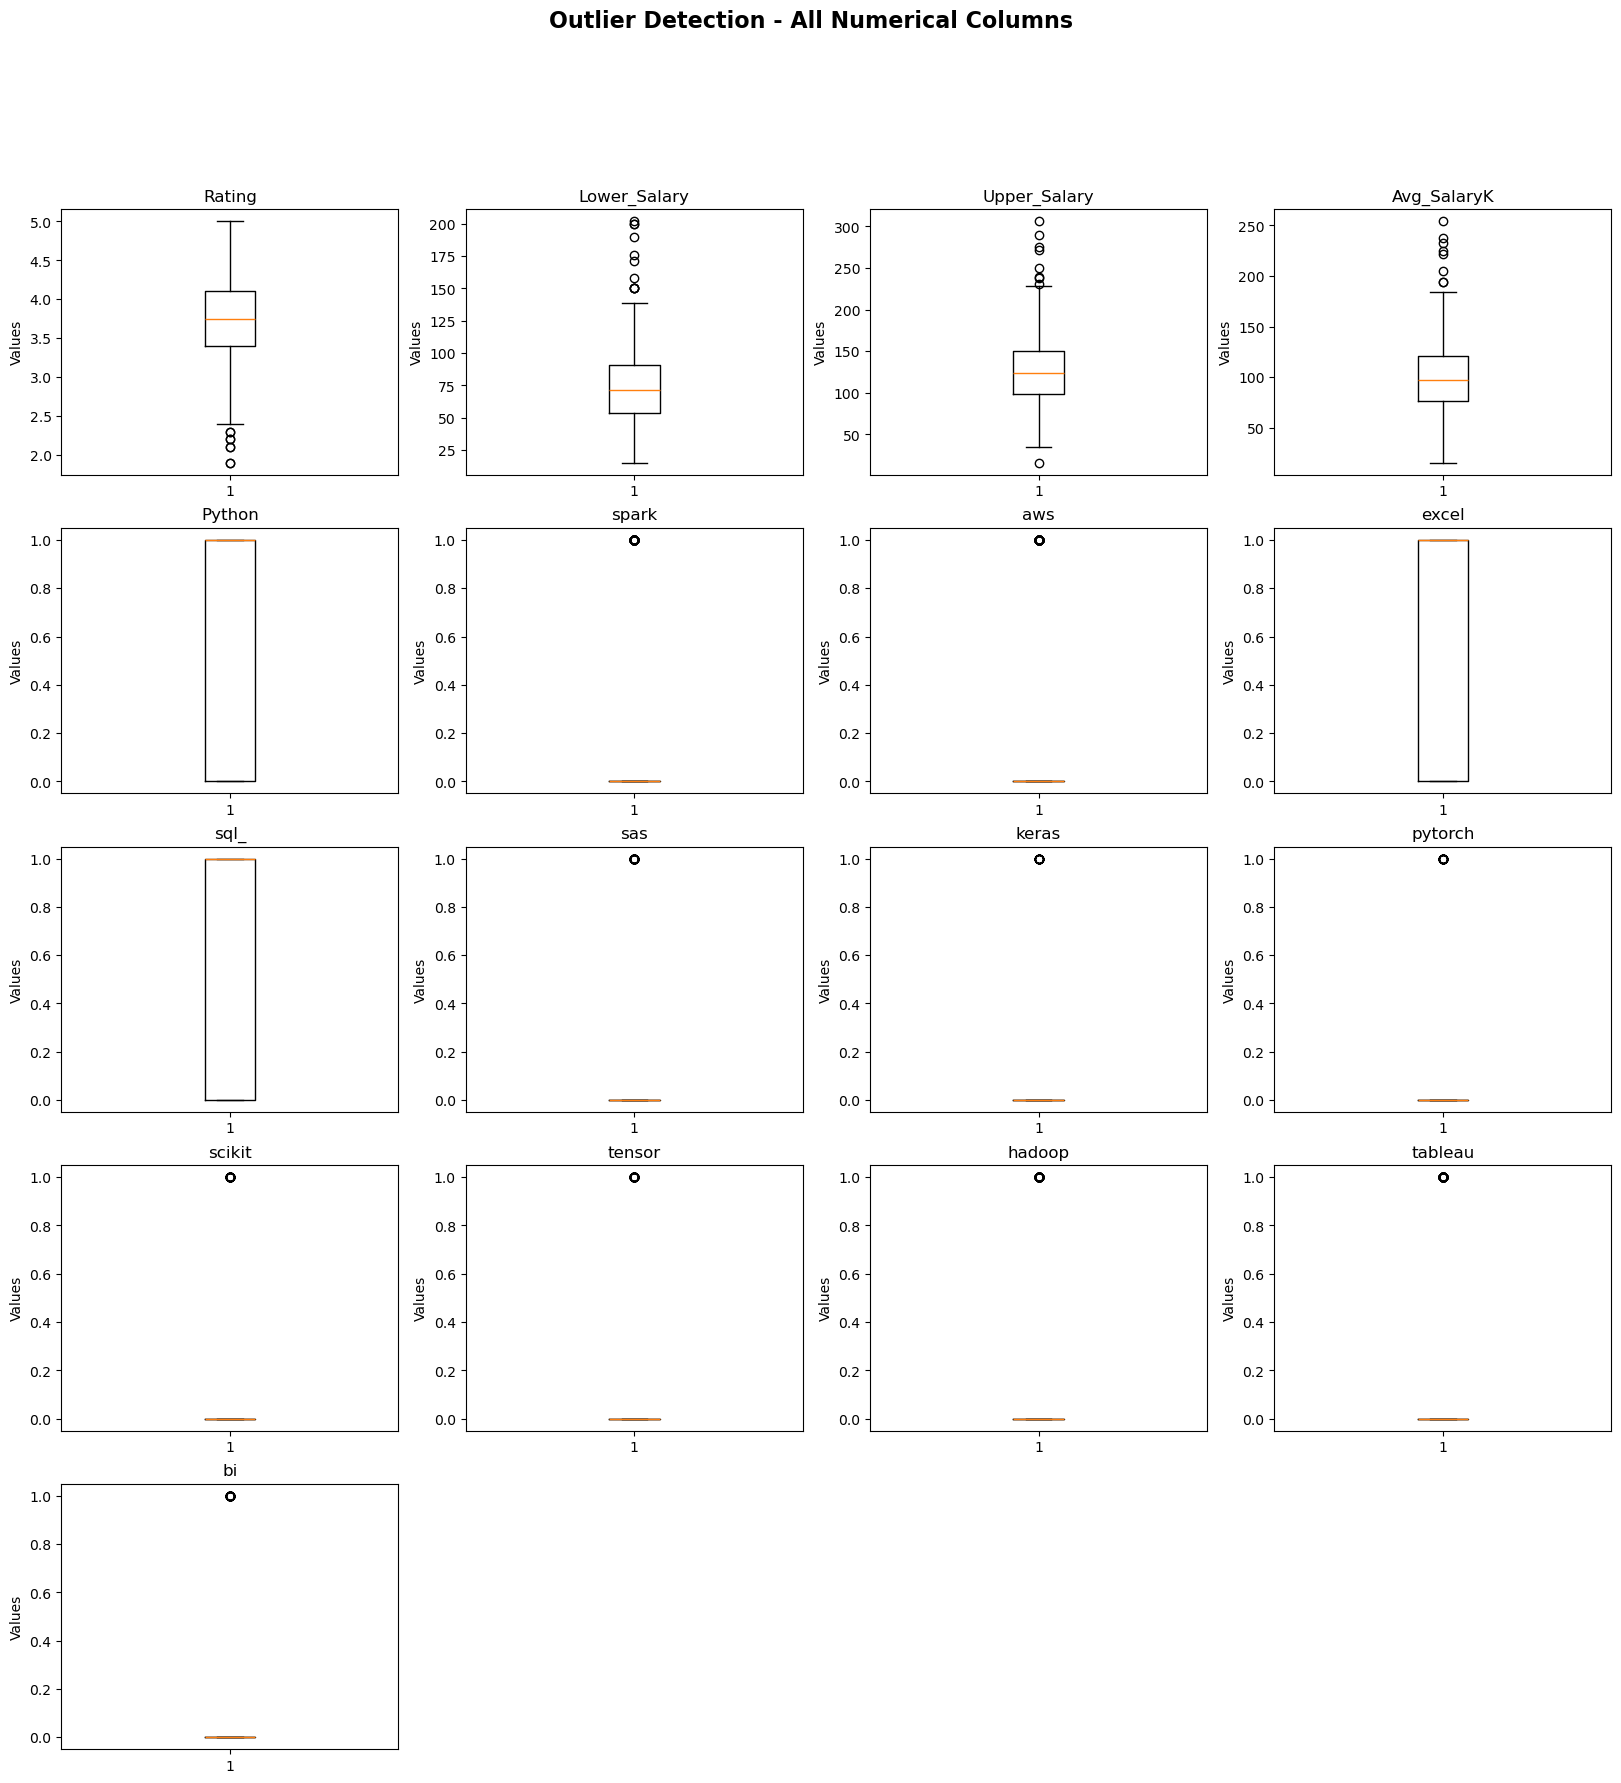

 Boxplot saved!


In [80]:
# Visualize outliers using Boxplots
import math

cols = 4
rows = math.ceil(len(num_cols) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel('Values')

# Hide empty subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Outlier Detection - All Numerical Columns',
             fontsize=16, fontweight='bold')
plt.savefig('outliers_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Boxplot saved!")

## Outlier Analysis - Decision

I checked the outliers in all numerical columns using the IQR method.
After analyzing the results, I decided to keep all the outliers.

### Why I am keeping the outliers?

- Rating: Some companies have very low ratings. 
  These are real ratings given by employees. 
  If I remove them, I will lose real information about bad companies.

- Lower Salary: Some jobs have very high minimum salaries. 
  These are real high paying Data Science jobs. 
  Removing them would give wrong salary insights.

- Upper Salary: Same reason as Lower Salary. 
  High salaries are real, not data entry errors.

- Avg Salary: High average salaries exist because of 
  senior level positions like Directors and ML Engineers.
  These are genuine values.

### My Conclusion:

Since this project is only for Data Visualization in Power BI,
outliers will not affect my charts or dashboard.
Keeping them will make my analysis more accurate and realistic.

## Step 9 - Saving the Cleaned Data
Saving the final cleaned dataset as a new CSV file for Power BI visualization.

In [20]:
# Save cleaned data
df.to_csv('cleaned_market_analysis.csv', index=False)
print(" Cleaned file saved successfully!")
print("Final Rows:", df.shape[0])
print("Final Columns:", df.shape[1])

 Cleaned file saved successfully!
Final Rows: 742
Final Columns: 42


In [21]:
# Final check of cleaned data
print("Final Dataset Info:")
print("-" * 40)
df.info()

Final Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 42 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  742 non-null    int64  
 1   Job_Title           742 non-null    object 
 2   Salary_Estimate     742 non-null    object 
 3   FIELD4              0 non-null      float64
 4   Rating              742 non-null    float64
 5   Company_Name        742 non-null    object 
 6   Location            742 non-null    object 
 7   Headquarters        742 non-null    object 
 8   Size                742 non-null    object 
 9   Founded             742 non-null    int64  
 10  Type_of_ownership   742 non-null    object 
 11  Industry            742 non-null    object 
 12  Sector              742 non-null    object 
 13  Revenue             742 non-null    object 
 14  Competitors         742 non-null    object 
 

In [22]:
# See final cleaned data
df.head()

,ID,Job_Title,Salary_Estimate,FIELD4,Rating,Company_Name,Location,Headquarters,Size,Founded,...,tensor,hadoop,tableau,bi,flink,mongo,google_an,job_title_sim,seniority_by_title,Degree
0,0,Data Scientist,$53K-$91K (Glassdoor est.),NaN,3.8,Tecolote Research,"Albuquerque, Nm","Goleta, CA",501 - 1000,1973,...,0,0,1,1,0,0,0,Data Scientist,Na,M
1,1,Healthcare Data Scientist,$63K-$112K (Glassdoor est.),NaN,3.4,University Of Maryland Medical System,"Linthicum, Md","Baltimore, MD",10000+,1984,...,0,0,0,0,0,0,0,Data Scientist,Na,M
2,2,Data Scientist,$80K-$90K (Glassdoor est.),NaN,4.8,Knowbe4,"Clearwater, Fl","Clearwater, FL",501 - 1000,2010,...,0,0,0,0,0,0,0,Data Scientist,Na,M
3,3,Data Scientist,$56K-$97K (Glassdoor est.),NaN,3.8,Pnnl,"Richland, Wa","Richland, WA",1001 - 5000,1965,...,0,0,0,0,0,0,0,Data Scientist,Na,NA
4,4,Data Scientist,$86K-$143K (Glassdoor est.),NaN,2.9,Affinity Solutions,"New York, Ny","New York, NY",51 - 200,1998,...,0,0,0,0,0,0,0,Data Scientist,Na,NA


## Step 9 - Final Data Validation
Confirming data is clean and ready for visualization.

In [23]:
print("=" * 40)
print("FINAL DATA VALIDATION REPORT")
print("=" * 40)
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"Data Types:\n{df.dtypes.value_counts()}")
print("=" * 40)
if df.isnull().sum().sum() == 0 and df.duplicated().sum() == 0:
    print(" DATA IS CLEAN AND READY!")
else:
    print(" DATA STILL HAS ISSUES!")
print("=" * 40)

FINAL DATA VALIDATION REPORT
Total Rows: 742
Total Columns: 42
Missing Values: 742
Duplicate Rows: 0
Data Types:
int64      23
object     16
float64     3
Name: count, dtype: int64
 DATA STILL HAS ISSUES!


## Step 10 - Saving the Cleaned Data
Saving final cleaned dataset for Power BI visualization.

In [81]:
# Save as Excel file instead of CSV
df.to_excel('cleaned_market_analysis.xlsx', index=False)
print("✅ Excel file saved!")
print("Total Rows:", df.shape[0])
print("Total Columns:", df.shape[1])

✅ Excel file saved!
Total Rows: 467
Total Columns: 26


In [82]:
# Final view of cleaned data
print("Sample of Cleaned Data:")
df.head()

Sample of Cleaned Data:


,Job_Title,Rating,Company_Name,Location,Industry,Sector,Lower_Salary,Upper_Salary,Avg_SalaryK,Job_Location,...,keras,pytorch,scikit,tensor,hadoop,tableau,bi,job_title_sim,seniority_by_title,Degree
0,Data Scientist,3.8,Tecolote Research,"Albuquerque, Nm",Aerospace & Defense,Aerospace & Defense,53,91,72.0,NM,...,0,0,0,0,0,1,1,Data Scientist,Na,M
1,Healthcare Data Scientist,3.4,University Of Maryland Medical System,"Linthicum, Md",Health Care Services & Hospitals,Health Care,63,112,87.5,MD,...,0,0,0,0,0,0,0,Data Scientist,Na,M
2,Data Scientist,4.8,Knowbe4,"Clearwater, Fl",Security Services,Business Services,80,90,85.0,FL,...,0,0,0,0,0,0,0,Data Scientist,Na,M
3,Data Scientist,3.8,Pnnl,"Richland, Wa",Energy,"Oil, Gas, Energy & Utilities",56,97,76.5,WA,...,0,0,0,0,0,0,0,Data Scientist,Na,NA
4,Data Scientist,2.9,Affinity Solutions,"New York, Ny",Advertising & Marketing,Business Services,86,143,114.5,NY,...,0,0,0,0,0,0,0,Data Scientist,Na,NA


## Conclusion

In this project, I analyzed the Data Science Job Market 
using a dataset of 742 job postings across the United States.

### What I did:
- Loaded and explored the raw dataset
- Dropped unnecessary columns that were not needed for analysis
- Checked and handled missing values
- Removed duplicate rows
- Standardized all categorical columns
- Checked outliers using boxplots and IQR method
- Saved the final cleaned dataset for Power BI visualization

### What I found:
- California has the most Data Science jobs (152)
- Biotech & Pharma is the top hiring industry
- Python and SQL are the most in-demand skills
- PhD holders earn the highest average salary ($116K)
- Data Scientist is the most common job title (313 jobs)

### Tools Used:
- Python (Pandas, NumPy, Matplotlib)
- Power BI (Dashboard & Visualization)
- MySQL (Data Source)

### Files:
- market_analysis.csv - Original dataset
- cleaned_market_analysis.csv - Cleaned dataset
- Job_Market_Analysis.ipynb - This notebook
- Job_Market_Analysis.pptx - Presentation
- Job_Market_Analysis_Insights.docx - Insights report